# Tutorial

In [3]:
from PriceFM import *
import pandas as pd
import numpy as np

# 3 folds
train_val_test_splits = [("2022-01-01", "2024-09-01", "2024-09-01", "2025-01-01", "2025-01-01", "2025-05-01"),
                         ("2022-01-01", "2025-01-01", "2025-01-01", "2025-05-01", "2025-05-01", "2025-09-01"),
                         ("2022-01-01", "2025-05-01", "2025-05-01", "2025-09-01", "2025-09-01", "2026-01-01")]

train_start, train_end, val_start, val_end, test_start, test_end = train_val_test_splits[0]

train_start, train_end = "2025-01-01", "2025-07-01"
val_start, val_end     = "2025-07-01", "2025-09-01",
test_start, test_end   = "2025-09-01", "2026-01-01"


countries = [
    "AT", "BE", "BG", "CZ", "DE_LU", "DK_1", "DK_2",
    "EE", "ES", "FI", "FR", "GR",    "HR", "HU", 
    "IT_CALA", "IT_CNOR", "IT_CSUD", "IT_NORD", "IT_SARD", "IT_SICI", "IT_SUD", 
    "LT", "LV", "NL", "NO_1", "NO_2", "NO_3", "NO_4", "NO_5", 
    "PL", "PT", "RO", "SE_1", "SE_2", "SE_3", "SE_4", "SI", "SK", 
]

countries = [
    "AT", "BE", "DE_LU", 
]


label_column = "price"
lag_features  = ["price", "load",  "solar", "wind"]
lead_features = ["load",  "solar", "wind"]

#lag_features  = ["price", "load",  "solar", "wind", "generation"]
#lead_features = ["load",  "solar", "wind", "generation"]

features = sorted((set(lag_features) | set(lead_features)) - {label_column})

lag_window      = 96
lead_window     = 96

rolling_train = {}
rolling_val   = {}
rolling_test  = {}

adjacency_dict = graph_adj_matrix()

# Data processing

- read data
- split into train, val, test
- scale
- separate by country code
- rolling window to create samples

In [4]:
# read df
df = read_dataset('Data/FINAL.csv')

# split into train val test
df_train, df_val, df_test = split_dataframe(df, train_start, train_end, val_start, val_end, test_start, test_end)

# scale df
#df_train_s, df_val_s, df_test_s, x_scaler, y_scaler = scale_dataframe_eu_level(df_train, df_val, df_test)
df_train_s, df_val_s, df_test_s, x_scalers, y_scalers = scale_dataframe_per_country(df_train, df_val, df_test, countries, features, label_column)

# separate each country
train_sep = separate_countries(df_train_s, countries, features, label_column)
val_sep   = separate_countries(df_val_s,   countries, features, label_column)
test_sep  = separate_countries(df_test_s,  countries, features, label_column)

# rolling window
for c in countries:
    X_lag_tr, X_lead_tr, Y_tr, t_tr = make_rolling_window_samples(
        train_sep[c], c, lag_features, lead_features, label_column, lag_window, lead_window
    )
    X_lag_va, X_lead_va, Y_va, t_va = make_rolling_window_samples(
        val_sep[c],   c, lag_features, lead_features, label_column, lag_window, lead_window
    )
    X_lag_te, X_lead_te, Y_te, t_te = make_rolling_window_samples(
        test_sep[c],  c, lag_features, lead_features, label_column, lag_window, lead_window
    )

    rolling_train[c] = {"X_lag": X_lag_tr, "X_lead": X_lead_tr, "Y": Y_tr, "t": t_tr}
    rolling_val[c]   = {"X_lag": X_lag_va, "X_lead": X_lead_va, "Y": Y_va, "t": t_va}
    rolling_test[c]  = {"X_lag": X_lag_te, "X_lead": X_lead_te, "Y": Y_te, "t": t_te}

# add graph adjacency to rolling_train/val/test
df_train, df_val, df_test = add_adj_dict_to_rollings(
    adjacency_dict,
    rolling_train,
    rolling_val,
    rolling_test,
    countries,
)

# Modeling & Evaluation

## 1. Pretraining

### requirement:

input_countries_pretrain == output_countries_pretrain == output_countries_test <- 'all countries'

In [6]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 2, 128

input_countries_pretrain = countries
output_countries_pretrain = countries
output_countries_test = countries

test_metrics = pipline_phase_I(input_countries_pretrain, output_countries_pretrain, output_countries_test, 
                                df_train, df_val, df_test, y_scalers, 
                                emb_dim, num_experts, epochs, batch_size, quantiles)

rows = []
for c in output_countries_test:
    rows.append({
        "target_country": c,
        **test_metrics[c]
    })

df_results = pd.DataFrame(rows)
df_results.to_csv("Result/phase1_pretraining.csv", index=False)
print("\nSaved:", "Result/phase1_pretraining.csv")

# average metrics 
avg_test_metrics = {
    k: float(np.mean([test_metrics[c][k] for c in output_countries_test]))
    for k in next(iter(test_metrics.values())).keys()
}
print("Average metrics:", avg_test_metrics)


=== Phase I: Pretraining ===
Input  Countries for Pretraining: ['AT', 'BE', 'DE_LU']
Output Countries for Pretraining: ['AT', 'BE', 'DE_LU']
Output Countries for Testing: ['AT', 'BE', 'DE_LU']

Epoch 1: val_loss improved from inf to 0.21384, saving model to Model/PhaseI_best.keras

Epoch 2: val_loss improved from 0.21384 to 0.17322, saving model to Model/PhaseI_best.keras

=== Evaluation for AT ===
AQL  : 10.207504
RMSE : 36.086819

=== Evaluation for BE ===
AQL  : 10.570552
RMSE : 34.656548

=== Evaluation for DE_LU ===
AQL  : 11.360828
RMSE : 41.731327

=== EU-level Average (mean over countries) ===
AQL                 : 10.712962
RMSE                : 37.491564

Saved: Result/phase1_pretraining.csv
Average metrics: {'AQL': 10.712961649334892, 'RMSE': 37.491564432779946}


0.07175
0.076
0.067

## 2. zero-shot (leave-one-out)

### requirement:

input_countries_pretrain == output_countries_pretrain <- 'countries excluding target country'
output_countries_test <- 'target country'

In [8]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 2, 128


all_test_metrics = {}
rows = []

for country in countries: 
    input_countries_pretrain = exclude_target_country(countries, country)
    output_countries_pretrain = input_countries_pretrain
    output_countries_test = [country]

    test_metrics = pipline_phase_I(input_countries_pretrain, output_countries_pretrain, output_countries_test, 
                                   df_train, df_val, df_test, y_scalers, 
                                   emb_dim, num_experts, epochs, batch_size, quantiles)
    all_test_metrics[country] =  test_metrics[country]  
    rows.append({
        "target_country": country,
        **all_test_metrics[country],
    })
avg_test_metrics = {k: float(np.mean([all_test_metrics[c][k] for c in all_test_metrics])) for k in next(iter(all_test_metrics.values())).keys()}

print("Per-country metrics:", all_test_metrics)
print("Average metrics:", avg_test_metrics)

# ---- Save final CSV
df_results = pd.DataFrame(rows)
df_results.to_csv("Result/phase1_zero_shot.csv", index=False)
print("\nSaved:", "Result/phase1_zero_shot.csv")


=== Phase I: Pretraining ===
Input  Countries for Pretraining: ['BE', 'DE_LU']
Output Countries for Pretraining: ['BE', 'DE_LU']
Output Countries for Testing: ['AT']

Epoch 1: val_loss improved from inf to 0.22986, saving model to Model/PhaseI_AT.keras

Epoch 2: val_loss improved from 0.22986 to 0.18433, saving model to Model/PhaseI_AT.keras

=== Evaluation for AT ===
AQL  : 11.332670
RMSE : 39.827335

=== EU-level Average (mean over countries) ===
AQL                 : 11.332670
RMSE                : 39.827335

=== Phase I: Pretraining ===
Input  Countries for Pretraining: ['AT', 'DE_LU']
Output Countries for Pretraining: ['AT', 'DE_LU']
Output Countries for Testing: ['BE']

Epoch 1: val_loss improved from inf to 0.26161, saving model to Model/PhaseI_BE.keras

Epoch 2: val_loss improved from 0.26161 to 0.21328, saving model to Model/PhaseI_BE.keras

=== Evaluation for BE ===
AQL  : 12.765388
RMSE : 40.046650

=== EU-level Average (mean over countries) ===
AQL                 : 12.765

## 3. full-shot

### requirement:

input_countries == target_countries == countries <- 'all countries'

In [9]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 2, 128
graph_degrees = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
graph_degrees = [0, 1]

input_countries = countries
target_countries = countries

for target_country in target_countries:
    rows = []
    for graph_degree in graph_degrees:
        metrics = pipline_phase_II(input_countries, target_country, adjacency_dict, graph_degree, 
                                df_train, df_val, df_test, y_scalers, 
                                emb_dim, num_experts, epochs, batch_size, quantiles)
        metrics = metrics[target_country] 
        row = {
            "target_country": target_country,
            "degree": graph_degree,
            **metrics,
        }
        rows.append(row)

    import pandas as pd
    df_results = pd.DataFrame(rows)
    df_results.to_csv(f"Result/phase2_{target_country}.csv", index=False)
    print("\nSaved:", f"Result/phase2_{target_country}.csv")


=== Phase II: Fine-Tuning ===
Input Countries: ['AT', 'BE', 'DE_LU']
Target country: AT
Graph degree: 0
0.20320066809654236

Epoch 1: val_loss improved from inf to 0.26686, saving model to Model/phase2_best_AT_deg0.keras

Epoch 2: val_loss improved from 0.26686 to 0.20469, saving model to Model/phase2_best_AT_deg0.keras

=== Evaluation for AT ===
AQL  : 10.090987
RMSE : 35.136436

=== EU-level Average (mean over countries) ===
AQL                 : 10.090987
RMSE                : 35.136436

=== Phase II: Fine-Tuning ===
Input Countries: ['AT', 'BE', 'DE_LU']
Target country: AT
Graph degree: 1
0.1806229203939438

Epoch 1: val_loss improved from inf to 0.23760, saving model to Model/phase2_best_AT_deg1.keras

Epoch 2: val_loss improved from 0.23760 to 0.19930, saving model to Model/phase2_best_AT_deg1.keras

=== Evaluation for AT ===
AQL  : 9.469739
RMSE : 34.721119

=== EU-level Average (mean over countries) ===
AQL                 : 9.469739
RMSE                : 34.721119

Saved: Res

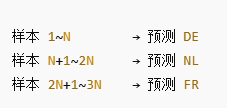

In [ ]:
#import netron
#netron.start(f"ckpt_place")

Serving 'phase1_best.keras' at http://localhost:8080


('localhost', 8080)